In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Recreate cleaned data
np.random.seed(42)
n = 303

data = {
    'age': np.random.randint(29, 77, n),
    'sex': np.random.choice([0, 1], n, p=[0.32, 0.68]),
    'cp': np.random.choice([0,1,2,3], n, p=[0.47,0.17,0.28,0.08]),
    'trestbps': np.random.normal(131, 17, n).astype(int).astype(float),
    'chol': np.random.normal(246, 51, n).astype(int).astype(float),
    'fbs': np.random.choice([0, 1], n, p=[0.85, 0.15]),
    'restecg': np.random.choice([0,1,2], n, p=[0.50,0.48,0.02]),
    'thalach': np.random.normal(149, 22, n).astype(int).astype(float),
    'exang': np.random.choice([0, 1], n, p=[0.67, 0.33]),
    'oldpeak': np.round(np.random.exponential(1.0, n), 1),
    'slope': np.random.choice([0,1,2], n, p=[0.21,0.46,0.33]),
    'ca': np.random.choice([0,1,2,3], n, p=[0.58,0.22,0.13,0.07]).astype(float),
    'thal': np.random.choice([0,1,2,3], n, p=[0.01,0.06,0.72,0.21]).astype(float),
    'target': np.random.choice([0, 1], n, p=[0.46, 0.54])
}

df = pd.DataFrame(data)

# Clean
df = df.drop_duplicates()
for col in ['trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'thal']:
    df[col].fillna(df[col].median(), inplace=True)
df.loc[df['chol'] > 500, 'chol'] = df['chol'].median()
df.loc[df['chol'] <= 0, 'chol'] = df['chol'].median()
df.loc[df['trestbps'] > 200, 'trestbps'] = df['trestbps'].median()
df.loc[df['trestbps'] <= 0, 'trestbps'] = df['trestbps'].median()
df.loc[df['thalach'] > 200, 'thalach'] = df['thalach'].median()
df.loc[df['thalach'] < 60, 'thalach'] = df['thalach'].median()

df.to_csv('heart_disease_clean.csv', index=False)
print("Data ready! Shape:", df.shape)

Data ready! Shape: (303, 14)


/tmp/ipykernel_3261/2857823370.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('heart_disease_clean.csv')

# Basic info
print("Shape:", df.shape)
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Statistical Summary ---")
print(df.describe())
print("\n--- Missing Values ---")
print(df.isnull().sum())

Shape: (303, 14)

--- Data Types ---
age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object

--- Statistical Summary ---
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    52.267327    0.709571    0.930693  131.594059  250.508251    0.141914   
std     13.896179    0.454711    1.031851   16.655953   51.862009    0.349539   
min     29.000000    0.000000    0.000000   85.000000   98.000000    0.000000   
25%     40.000000    0.000000    0.000000  121.000000  215.500000    0.000000   
50%     53.000000    1.000000    1.000000  131.000000  251.000000    0.000000   
75%     64.000000    1.000000    2.000000  142.000000  284.000000    0.00

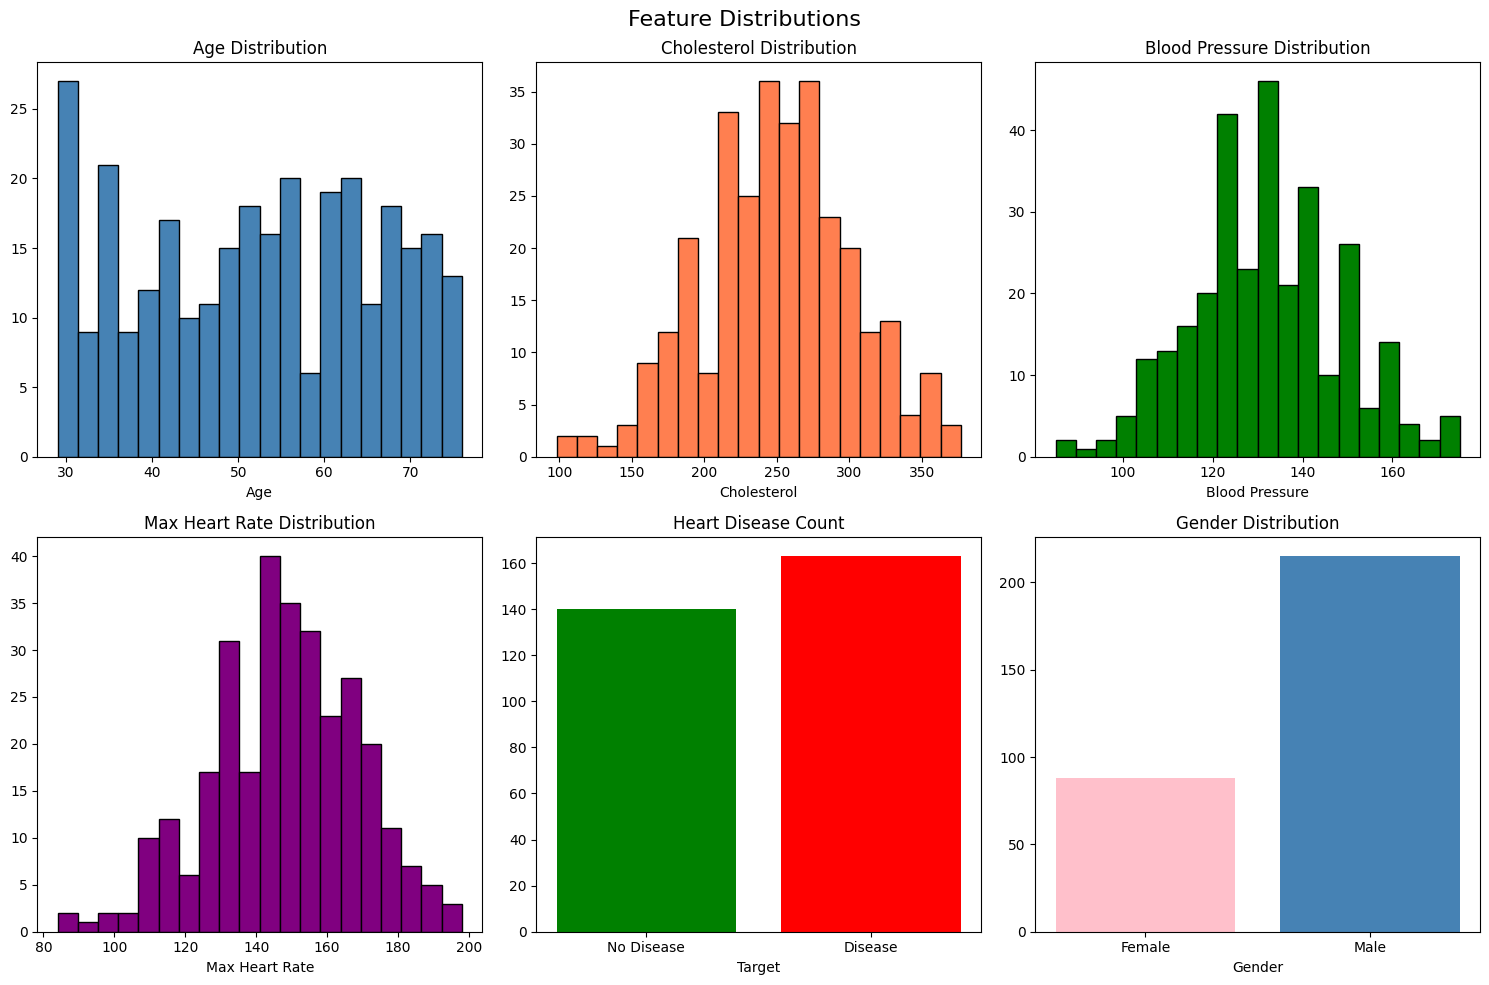

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Feature Distributions', fontsize=16)

# Age distribution
axes[0,0].hist(df['age'], bins=20, color='steelblue', edgecolor='black')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')

# Cholesterol distribution
axes[0,1].hist(df['chol'], bins=20, color='coral', edgecolor='black')
axes[0,1].set_title('Cholesterol Distribution')
axes[0,1].set_xlabel('Cholesterol')

# Blood Pressure distribution
axes[0,2].hist(df['trestbps'], bins=20, color='green', edgecolor='black')
axes[0,2].set_title('Blood Pressure Distribution')
axes[0,2].set_xlabel('Blood Pressure')

# Max Heart Rate distribution
axes[1,0].hist(df['thalach'], bins=20, color='purple', edgecolor='black')
axes[1,0].set_title('Max Heart Rate Distribution')
axes[1,0].set_xlabel('Max Heart Rate')

# Target distribution
axes[1,1].bar(['No Disease', 'Disease'],
              df['target'].value_counts().sort_index(),
              color=['green', 'red'])
axes[1,1].set_title('Heart Disease Count')
axes[1,1].set_xlabel('Target')

# Gender distribution
axes[1,2].bar(['Female', 'Male'],
              df['sex'].value_counts().sort_index(),
              color=['pink', 'steelblue'])
axes[1,2].set_title('Gender Distribution')
axes[1,2].set_xlabel('Gender')

plt.tight_layout()
plt.show()

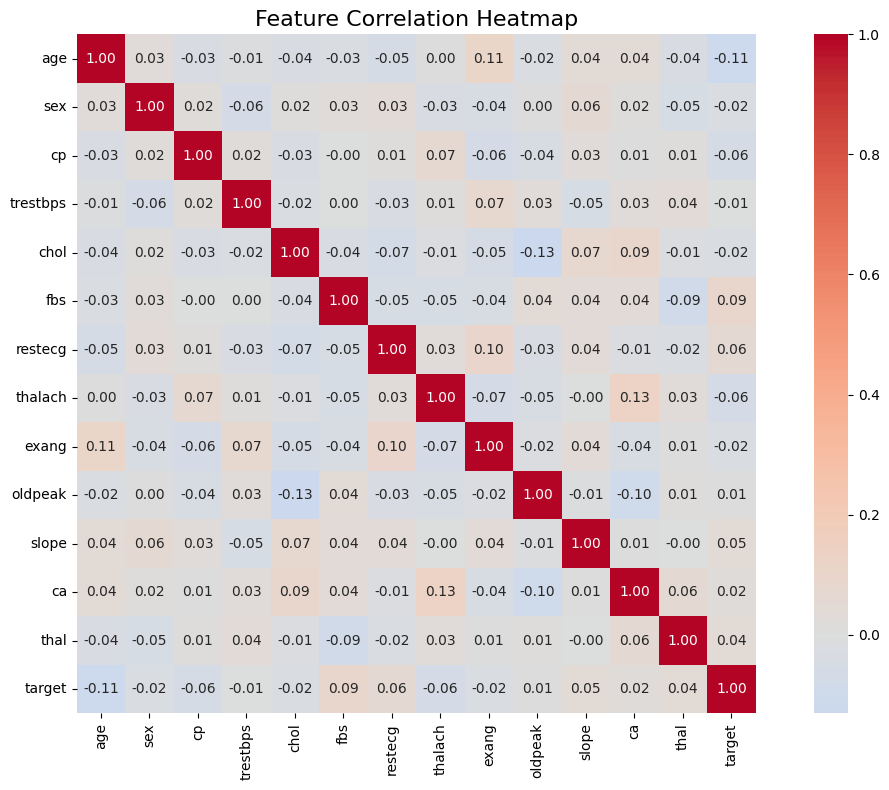

In [5]:
plt.figure(figsize=(12, 8))
correlation = df.corr(numeric_only=True)
sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3261/2624706656.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,0].boxplot([df[df['target']==0]['age'],
/tmp/ipykernel_3261/2624706656.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot([df[df['target']==0]['chol'],
/tmp/ipykernel_3261/2624706656.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot([df[df['target']==0]['thalach'],


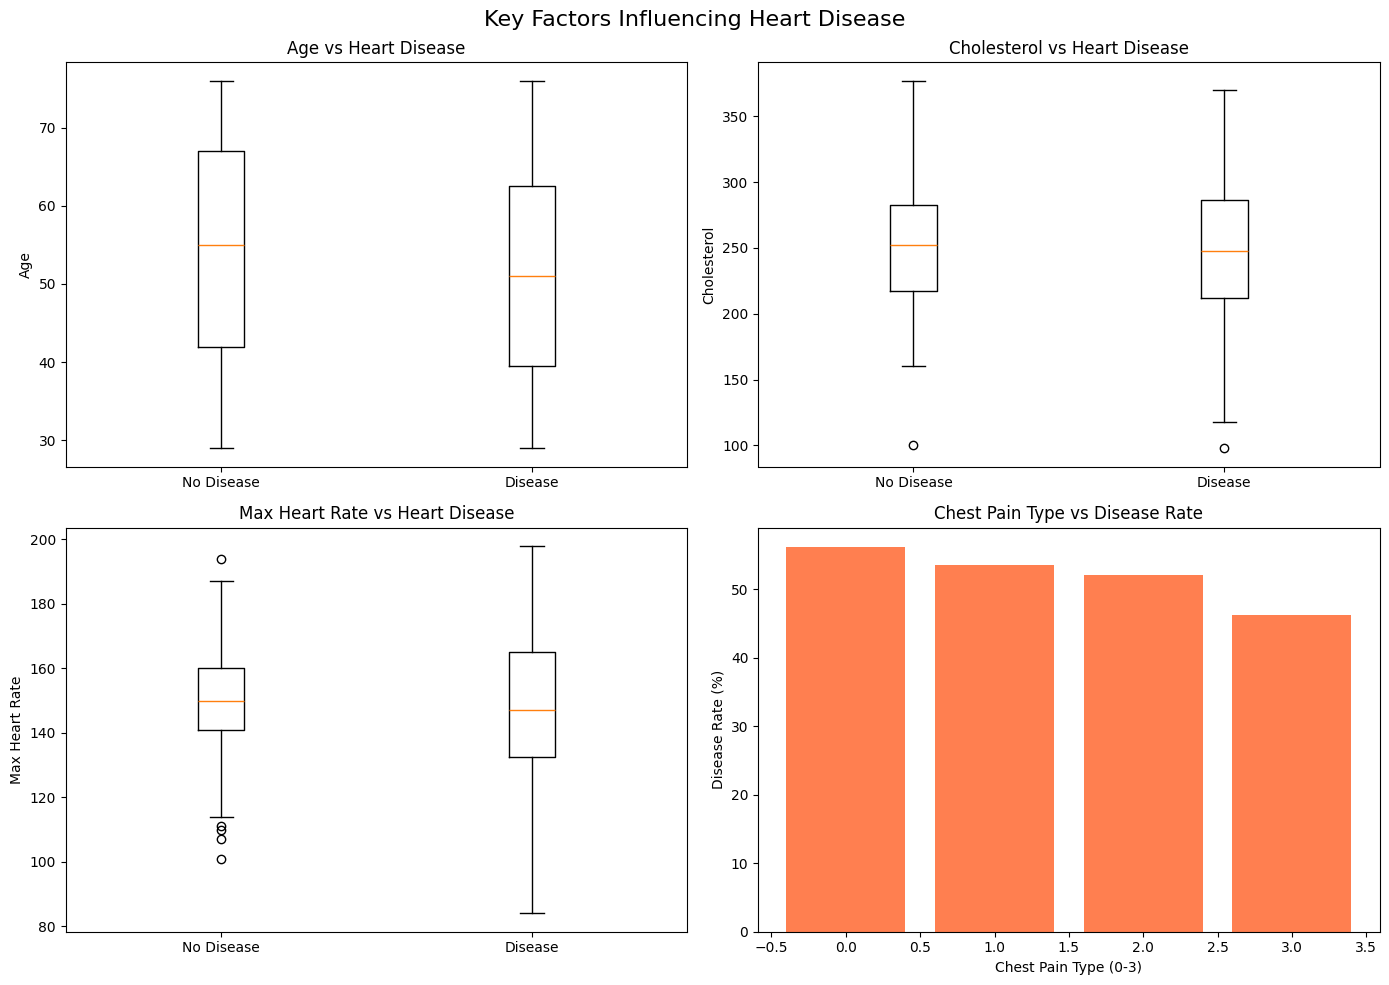

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Key Factors Influencing Heart Disease', fontsize=16)

# Age vs Heart Disease
axes[0,0].boxplot([df[df['target']==0]['age'],
                   df[df['target']==1]['age']],
                   labels=['No Disease', 'Disease'])
axes[0,0].set_title('Age vs Heart Disease')
axes[0,0].set_ylabel('Age')

# Cholesterol vs Heart Disease
axes[0,1].boxplot([df[df['target']==0]['chol'],
                   df[df['target']==1]['chol']],
                   labels=['No Disease', 'Disease'])
axes[0,1].set_title('Cholesterol vs Heart Disease')
axes[0,1].set_ylabel('Cholesterol')

# Max Heart Rate vs Heart Disease
axes[1,0].boxplot([df[df['target']==0]['thalach'],
                   df[df['target']==1]['thalach']],
                   labels=['No Disease', 'Disease'])
axes[1,0].set_title('Max Heart Rate vs Heart Disease')
axes[1,0].set_ylabel('Max Heart Rate')

# Chest Pain Type vs Heart Disease
cp_disease = df.groupby('cp')['target'].mean() * 100
axes[1,1].bar(cp_disease.index, cp_disease.values, color='coral')
axes[1,1].set_title('Chest Pain Type vs Disease Rate')
axes[1,1].set_xlabel('Chest Pain Type (0-3)')
axes[1,1].set_ylabel('Disease Rate (%)')

plt.tight_layout()
plt.show()

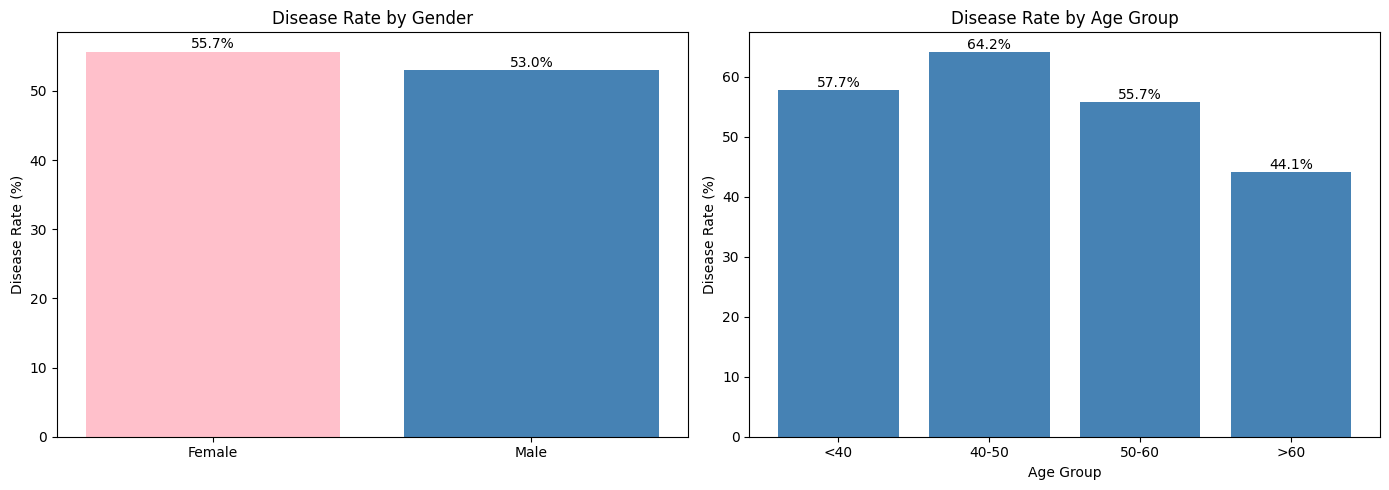

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender vs Disease Rate
gender_disease = df.groupby('sex')['target'].mean() * 100
axes[0].bar(['Female', 'Male'], gender_disease.values,
            color=['pink', 'steelblue'])
axes[0].set_title('Disease Rate by Gender')
axes[0].set_ylabel('Disease Rate (%)')
for i, v in enumerate(gender_disease.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center')

# Age Group vs Disease Rate
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 40, 50, 60, 100],
                          labels=['<40', '40-50', '50-60', '>60'])
age_disease = df.groupby('age_group', observed=True)['target'].mean() * 100
axes[1].bar(age_disease.index, age_disease.values, color='steelblue')
axes[1].set_title('Disease Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Disease Rate (%)')
for i, v in enumerate(age_disease.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

In [9]:
print("=" * 50)
print("KEY INSIGHTS FROM EDA")
print("=" * 50)

print(f"\n1. DATASET: {df.shape[0]} patients, {df.shape[1]} features")

disease_rate = df['target'].mean() * 100
print(f"\n2. DISEASE RATE: {disease_rate:.1f}% patients have heart disease")

avg_age_disease = df[df['target']==1]['age'].mean()
avg_age_no_disease = df[df['target']==0]['age'].mean()
print(f"\n3. AGE:")
print(f"   - With disease: avg age {avg_age_disease:.1f}")
print(f"   - Without disease: avg age {avg_age_no_disease:.1f}")

male_rate = df[df['sex']==1]['target'].mean() * 100
female_rate = df[df['sex']==0]['target'].mean() * 100
print(f"\n4. GENDER:")
print(f"   - Male disease rate: {male_rate:.1f}%")
print(f"   - Female disease rate: {female_rate:.1f}%")

top_corr = correlation['target'].abs().sort_values(ascending=False)[1:4]
print(f"\n5. TOP CORRELATED FEATURES with Heart Disease:")
for feat, val in top_corr.items():
    print(f"   - {feat}: {val:.2f}")

print("\n" + "=" * 50)

KEY INSIGHTS FROM EDA

1. DATASET: 303 patients, 15 features

2. DISEASE RATE: 53.8% patients have heart disease

3. AGE:
   - With disease: avg age 50.8
   - Without disease: avg age 54.0

4. GENDER:
   - Male disease rate: 53.0%
   - Female disease rate: 55.7%

5. TOP CORRELATED FEATURES with Heart Disease:
   - age: 0.11
   - fbs: 0.09
   - thalach: 0.06

